# Remote sensing data

<!-- markdownlint-disable MD033-->
<div class="page-subtitle">
Searching, subsetting and visualising imagery before it enters your project workflow
</div>
<!-- markdownlint-enable MD033 -->

---

## Why this page matters

In the previous page, you defined search criteria for suitable spatial data. Here, you apply that logic to {term}`Remote Sensing` data.

Remote sensing datasets can be very useful for SDS320 projects, but they come with trade-offs. {term}`Spatial Resolution` determines which objects are visible. Temporal coverage determines whether you can observe the period of interest. Cloud cover affects usability. {term}`Spectral Bands <Spectral Band>` determine which surface properties you can analyse.

This page focuses on search, inspection, small subset downloads and quick visual checks. Full {term}`Preprocessing` comes later.

By the end of this page, you should be able to answer:

```text
Which imagery source fits my project, and can I retrieve a useful subset without downloading too much data?
```

---

## Core idea

Modern imagery access often follows a search-first workflow.

Instead of downloading a full scene immediately, you first search metadata, inspect candidate scenes, choose useful assets, and then retrieve only the area and bands you need.

A common workflow is:

```text
Choose source
→ search catalog
→ inspect collection
→ search items
→ inspect assets
→ load or download a small subset
→ visualise and check
→ document the decision
```

This is especially useful for cloud-hosted {term}`Cloud Optimized GeoTIFFs <Cloud Optimized GeoTIFF (COG)>`, where Python can read only a spatial window from a large remote file.

```{tip}
In your project notes, record not only which image you used, but also why you selected it: location, date range, cloud cover, bands, spatial resolution and main limitation.
```

---

## STAC in one minute

{term}`SpatioTemporal Asset Catalog (STAC)` is a standard way to describe and search geospatial assets.

A typical STAC structure is:

```text
Catalog
→ Collection
→ Item
→ Asset
```

| STAC level | Meaning |
|---|---|
| Catalog | Entry point to a data archive or API. |
| Collection | Dataset group, such as Sentinel-2, Landsat or NAIP. |
| Item | One scene, tile or observation with footprint and date. |
| Asset | One file connected to an item, such as a band, preview or metadata file. |

In practice, you connect to a catalog, choose a collection, search for items by area and time, inspect the assets, and then load or download the files that matter for your project.

---

## Explore the Planetary Computer catalogue

The Microsoft Planetary Computer hosts many Earth observation datasets and provides a STAC API.

Useful entry points:

- [Planetary Computer Data Catalog](https://planetarycomputer.microsoft.com/catalog)
- [Planetary Computer STAC API](https://planetarycomputer.microsoft.com/api/stac/v1)
- [Planetary Computer STAC documentation](https://planetarycomputer.microsoft.com/docs/quickstarts/reading-stac/)
- [Planetary Computer Data API documentation](https://planetarycomputer.microsoft.com/docs/quickstarts/using-the-data-api/)

Start with the online catalogue before writing code. It helps you understand which collections exist, what they contain and which collection IDs you need.

<!-- TODO: confirm whether `pystac-client`, `planetary-computer`, `rasterio`, `pyproj`, `requests` and `matplotlib` are included in the official SDS320 environment. -->

---

## Choose an imagery source

Common open or partly open sources include:

| Source | Typical use | Main limitation |
|---|---|---|
| {term}`Sentinel-2` | Multispectral land monitoring, vegetation, land cover and change detection. | Clouds and 10–20 m bands may limit small-object mapping. |
| Landsat | Long-term change analysis over decades. | Coarser multispectral resolution than Sentinel-2. |
| NAIP | High-resolution aerial imagery for the United States. | Coverage is limited to the United States. |
| SWISSIMAGE | Very high-resolution imagery for Switzerland. | Very large data volume at 10 cm resolution. |
| Vantor Open Data | Event-focused high-resolution imagery for selected disasters. | Coverage is limited to released events and licensing must be checked. |

Choose based on your project need, not only on popularity.

```{tip}
For a long time series, Landsat may be more useful than a higher-resolution but shorter archive. For small objects, moderate-resolution imagery may not be enough.
```

---

## Shared helper code for spatial subsets

The following helper functions demonstrate how to retrieve a spatial subset of large remote imagery files. They search STAC items, read only a spatial window of interest, write a local GeoTIFF, and display a quick visual preview.

You can configure the output dimensions to suit your needs—smaller subsets load faster and use less disk space, while larger subsets preserve more detail. These functions use spatial windowing to avoid downloading the entire scene. For final analysis, always verify the native resolution and document any resampling used.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from pyproj import Transformer
from rasterio.windows import from_bounds
from rasterio.windows import transform as window_transform


def bbox_to_dataset_crs(bbox_wgs84, dst_crs):
    """Transform a WGS84 bounding box to a raster's native CRS.

    Rasterio windows must be given in the source file's own CRS, not WGS84.

    Args:
        bbox_wgs84: Bounding box in WGS84 [min_lon, min_lat, max_lon, max_lat].
        dst_crs: Target CRS (e.g., src.crs from rasterio.open()).

    Returns:
        Bounding box in the target CRS [min_x, min_y, max_x, max_y].
    """
    transformer = Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)
    min_lon, min_lat, max_lon, max_lat = bbox_wgs84
    xs, ys = transformer.transform([min_lon, max_lon], [min_lat, max_lat])
    return min(xs), min(ys), max(xs), max(ys)


def ycbcr_to_rgb(stack):
    """Convert a 3-band YCbCr image (ITU-R BT.601) to RGB uint8.

    Some imagery (e.g. JPEG-compressed GeoTIFFs, as used by SWISSIMAGE) stores
    colour as YCbCr rather than RGB, and must be converted before it can be
    written or plotted as a normal RGB image.

    Args:
        stack: Array of shape (3, height, width) with YCbCr bands.

    Returns:
        RGB array of shape (3, height, width) as uint8.
    """
    y, cb, cr = stack.astype("float32")
    r = y + 1.402 * (cr - 128.0)
    g = y - 0.344136 * (cb - 128.0) - 0.714136 * (cr - 128.0)
    b = y + 1.772 * (cb - 128.0)
    return np.clip(np.stack([r, g, b]), 0, 255).astype("uint8")


def save_single_asset_subset(
    item, asset_key, bbox_wgs84, output_path, band_indexes=(1, 2, 3)
):
    """Read the AOI window from one raster asset and save it as a GeoTIFF.

    Output pixel dimensions follow the AOI at the source's native resolution,
    so a landscape bbox produces a landscape image (no separate width/height
    arguments needed).

    Args:
        item: A STAC Item object.
        asset_key: String key of the asset to read (e.g., 'B02', 'red', 'image').
        bbox_wgs84: Bounding box in WGS84 [min_lon, min_lat, max_lon, max_lat].
        output_path: File path for the output GeoTIFF.
        band_indexes: Tuple of band indices to read (1-indexed; default (1,2,3) for RGB).

    Returns:
        Path to the written GeoTIFF file.
    """
    href = item.assets[asset_key].href

    with rasterio.open(href) as src:
        print("Source CRS:", src.crs)
        bounds = bbox_to_dataset_crs(bbox_wgs84, src.crs)
        window = from_bounds(*bounds, transform=src.transform)

        stack = src.read(
            list(band_indexes), window=window, boundless=True, fill_value=0
        )
        print("Read shape, dtype:", stack.shape, stack.dtype)

        profile = src.profile.copy()
        profile.update(
            driver="GTiff",
            height=stack.shape[1],
            width=stack.shape[2],
            count=len(band_indexes),
            transform=window_transform(window, src.transform),
            compress="deflate",
        )
        profile.pop("photometric", None)

        if (
            str(src.profile.get("photometric", "")).lower() == "ycbcr"
            and stack.shape[0] == 3
        ):
            print("Converting YCbCr -> RGB")
            stack = ycbcr_to_rgb(stack)
        profile.update(dtype=str(stack.dtype))

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(stack)

    size_mb = output_path.stat().st_size / 1_000_000
    print(f"Saved: {output_path} ({size_mb:.2f} MB)")
    return output_path


def save_multiband_subset(item, asset_keys, bbox_wgs84, output_path):
    """Read the AOI window from several single-band assets and save as one GeoTIFF.

    Each asset key is read separately (one band each) and stacked in the given
    order, e.g. asset_keys=['B04', 'B03', 'B02'] for a red-green-blue stack.
    Output pixel dimensions follow the AOI at the source's native resolution.

    Args:
        item: A STAC Item object.
        asset_keys: Ordered list of asset keys, one per output band.
        bbox_wgs84: Bounding box in WGS84 [min_lon, min_lat, max_lon, max_lat].
        output_path: File path for the output GeoTIFF.

    Returns:
        Path to the written GeoTIFF file.
    """
    bands = []
    profile = None

    for key in asset_keys:
        with rasterio.open(item.assets[key].href) as src:
            bounds = bbox_to_dataset_crs(bbox_wgs84, src.crs)
            window = from_bounds(*bounds, transform=src.transform)
            band = src.read(1, window=window, boundless=True, fill_value=0)
            bands.append(band)

            if profile is None:
                profile = src.profile.copy()
                profile.update(
                    driver="GTiff",
                    height=band.shape[0],
                    width=band.shape[1],
                    count=len(asset_keys),
                    transform=window_transform(window, src.transform),
                    compress="deflate",
                )
                profile.pop("photometric", None)

    stack = np.stack(bands)
    profile.update(dtype=str(stack.dtype))

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(stack)

    size_mb = output_path.stat().st_size / 1_000_000
    print(f"Saved: {output_path} ({size_mb:.2f} MB)")
    return output_path


def stretch_rgb(rgb):
    """Apply a percentile stretch to an RGB image for better visual contrast.

    Raw satellite data often spans a wide dynamic range. A 2-98 percentile stretch clips
    extreme values and maps the middle 96% to the display range, improving visibility of
    detail without losing important information to saturation.

    Args:
        rgb: Array of shape (3, height, width) or (height, width, 3).

    Returns:
        Stretched array normalized to [0, 1].
    """
    rgb = np.moveaxis(rgb, 0, -1).astype("float32")
    p_low, p_high = np.nanpercentile(rgb, (2, 98))
    if p_high == p_low:
        return np.zeros_like(rgb)
    rgb = (rgb - p_low) / (p_high - p_low)
    return np.clip(rgb, 0, 1)


def plot_rgb(path, title):
    """Load a GeoTIFF and display it as an RGB image with percentile stretch.

    Args:
        path: File path to a 3-band GeoTIFF.
        title: Title for the plot.
    """
    with rasterio.open(path) as src:
        rgb = src.read([1, 2, 3])
    plt.figure(figsize=(7, 3))
    plt.imshow(stretch_rgb(rgb))
    plt.title(title)
    plt.axis("off")
    plt.show()

---

## Practical subset workflows

The following examples all follow the same pathway:

```text
define a small bounding box
→ search a catalogue
→ inspect the selected item
→ choose assets
→ save or visualise a subset
→ check whether the result is useful
```

Use them as patterns for your own project. The exact locations are examples, but the decisions are transferable.

---

### Sentinel-2 data: Rome

Sentinel-2 is a useful first example because it is global, multispectral and available through the Planetary Computer.

Here, the subset focuses on Rome. At 10 m resolution, a subset of approximately 1000 × 400 pixels covers several kilometres and shows the city pattern clearly.

In [ ]:
from pystac_client import Client
import planetary_computer as pc

pc_catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

rome_bbox = [12.42, 41.88, 12.52, 41.91]  # WGS84 lon/lat around Rome

search = pc_catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=rome_bbox,
    datetime="2025-06-01/2025-06-30",
    query={"eo:cloud_cover": {"lt": 20}},
    max_items=3,
)

items = list(search.items())
print(f"Found {len(items)} Sentinel-2 item(s)")


Found 3 Sentinel-2 item(s)
ID: S2C_MSIL2A_20250628T100051_R122_T33TTG_20250628T152517
 Date: 2025-06-28 10:00:51.025000+00:00
 Cloud cover: 1.8%
 Bounding box: [11.3549542, 41.4077262, 12.7230334, 42.4293609]

ID: S2C_MSIL2A_20250628T100051_R122_T32TQM_20250628T152517
 Date: 2025-06-28 10:00:51.025000+00:00
 Cloud cover: 2.0%
 Bounding box: [11.3934608, 41.4040347, 12.7631364, 42.426912]

ID: S2B_MSIL2A_20250623T100029_R122_T33TTG_20250623T121450
 Date: 2025-06-23 10:00:29.024000+00:00
 Cloud cover: 1.5%
 Bounding box: [11.3549542, 41.4077262, 12.7230334, 42.4293609]



Select the least-cloudy item and inspect its assets.

In [32]:
items_sorted = sorted(
    items,
    key=lambda item: item.properties.get("eo:cloud_cover", 999),
)

s2_item = pc.sign(items_sorted[0])

print("Selected item:", s2_item.id)
print("Date:", s2_item.datetime)
print("Cloud cover:", round(s2_item.properties.get("eo:cloud_cover"), 2))

print("\nUseful assets:")
for key in ["B02", "B03", "B04", "B08", "B11", "B12"]:
    if key in s2_item.assets:
        print(key, "-", s2_item.assets[key].title)

Selected item: S2B_MSIL2A_20250623T100029_R122_T33TTG_20250623T121450
Date: 2025-06-23 10:00:29.024000+00:00
Cloud cover: 1.48

Useful assets:
B02 - Band 2 - Blue - 10m
B03 - Band 3 - Green - 10m
B04 - Band 4 - Red - 10m
B08 - Band 8 - NIR - 10m
B11 - Band 11 - SWIR (1.6) - 20m
B12 - Band 12 - SWIR (2.2) - 20m


Download only a small RGB subset.

/var/folders/vm/lrq81ypd0gz9nnq4k4kv612m0000gr/T/ipykernel_35801/744485391.py:132: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = src.read(1, window=window, boundless=True, fill_value=0)


Saved: data/raw/sentinel2/s2_rome_rgb_subset.tif (1.20 MB)


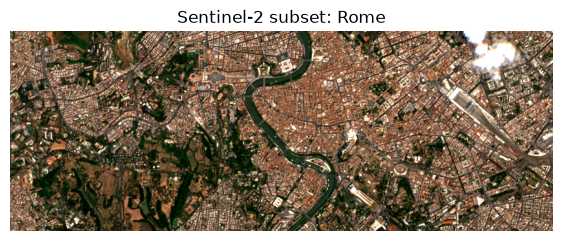

In [28]:
s2_subset = save_multiband_subset(
    item=s2_item,
    asset_keys=["B04", "B03", "B02"],  # red, green, blue
    bbox_wgs84=rome_bbox,
    output_path="data/raw/sentinel2/s2_rome_rgb_subset.tif",
)

plot_rgb(s2_subset, "Sentinel-2 subset: Rome")

Project check: if your project targets small objects such as individual trees, cars or buildings, Sentinel-2 may be too coarse. If your project targets broader land-cover patterns, vegetation, water or change, it may be a good candidate.

---

### Landsat data: Himalaya region

Landsat is useful when the time dimension matters. It has a long archive and global coverage, but coarser resolution than Sentinel-2.

Here, the subset focuses on the Mount Everest region in the Himalaya. The preview is useful for understanding terrain and glacier context, but 30 m pixels are not suitable for very small objects.

In [5]:
everest_bbox = [86.80, 27.90, 87.01, 27.98]  # WGS84 lon/lat around Mount Everest

search = pc_catalog.search(
    collections=["landsat-c2-l2"],
    bbox=everest_bbox,
    datetime="2026-07-01/2026-09-30",
    query={"eo:cloud_cover": {"lt": 30}},
    max_items=10,
)

items = list(search.items())
print(f"Found {len(items)} Landsat item(s)")

Found 1 Landsat item(s)


In [6]:
items_sorted = sorted(
    items,
    key=lambda item: item.properties.get("eo:cloud_cover", 999),
)

landsat_item = pc.sign(items_sorted[0])

print("Selected item:", landsat_item.id)
print("Date:", landsat_item.datetime)
print("Cloud cover:", landsat_item.properties.get("eo:cloud_cover"))

print("\nFirst asset keys:")
print(list(landsat_item.assets.keys())[:20])

Selected item: LC08_L2SP_140041_20260811_02_T1
Date: 2026-08-11 04:41:49.902009+00:00
Cloud cover: 26.16

First asset keys:
['qa', 'ang', 'red', 'blue', 'drad', 'emis', 'emsd', 'trad', 'urad', 'atran', 'cdist', 'green', 'nir08', 'lwir11', 'swir16', 'swir22', 'coastal', 'mtl.txt', 'mtl.xml', 'mtl.json']


For Landsat Collection 2 Level-2, common visible-band asset names are `red`, `green` and `blue`.

The notebook example below uses `swir22`, `nir08` and `red`. This is a false-colour composite, not a true-colour RGB image. It can be useful for highlighting snow, ice, rock and vegetation patterns, but the colours should be explained in captions and project notes.

/var/folders/vm/lrq81ypd0gz9nnq4k4kv612m0000gr/T/ipykernel_35801/744485391.py:132: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = src.read(1, window=window, boundless=True, fill_value=0)


Saved: data/raw/landsat/landsat_everest_rgb_subset.tif (1.16 MB)


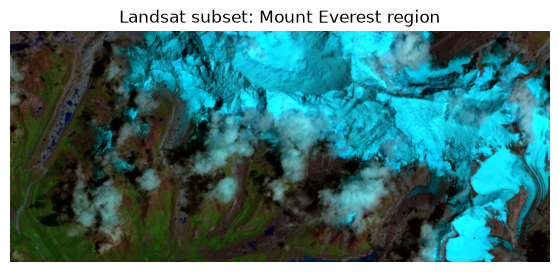

In [7]:
landsat_subset = save_multiband_subset(
    item=landsat_item,
    asset_keys=["swir22", "nir08", "red"],
    bbox_wgs84=everest_bbox,
    output_path="data/raw/landsat/landsat_everest_rgb_subset.tif",
)

plot_rgb(landsat_subset, "Landsat subset: Mount Everest region")

Project check: Landsat is strongest when you need temporal depth. Do not force it to answer questions that require very fine spatial detail.

```{tip}
For analysis, match the band combination to the project question. For visual inspection, false colour can be helpful. For communication, explain what the colours mean.
```

---

### NAIP data: New York

NAIP provides high-resolution aerial imagery for the United States. It is useful for fine spatial detail such as buildings, tree crowns and urban features.

Here, the subset focuses on the Statue of Liberty in New York Harbor.

In [8]:
nyc_bbox = [-74.050, 40.688, -74.039, 40.691]  # WGS84 lon/lat around Statue of Liberty

search = pc_catalog.search(
    collections=["naip"],
    bbox=nyc_bbox,
    datetime="2021-01-01/2024-12-31",
    max_items=10,
)

items = list(search.items())
print(f"Found {len(items)} NAIP item(s)")

Found 6 NAIP item(s)


In [9]:
naip_item = pc.sign(items[0])

print("Selected item:", naip_item.id)
print("Date:", naip_item.datetime)
print("\nAsset keys:")
print(list(naip_item.assets.keys()))

Selected item: nj_m_4007424_ne_18_030_20230820_20231019
Date: 2023-08-20 16:00:00+00:00

Asset keys:
['image', 'thumbnail', 'tilejson', 'rendered_preview']


NAIP items on the Planetary Computer typically include a multi-band image asset. Inspect asset keys first; in many cases the image asset is named `image`.

Source CRS: EPSG:26918
Read shape, dtype: (3, 1144, 3086) uint8
Saved: data/raw/naip/naip_statue_of_liberty_rgb_subset.tif (6.28 MB)


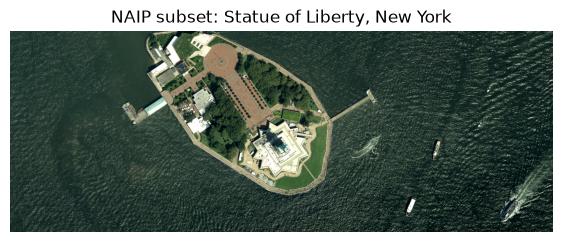

In [10]:
naip_asset_key = "image"

if naip_asset_key not in naip_item.assets:
    raise KeyError(f"Check available NAIP assets: {list(naip_item.assets.keys())}")

naip_subset = save_single_asset_subset(
    item=naip_item,
    asset_key=naip_asset_key,
    bbox_wgs84=nyc_bbox,
    output_path="data/raw/naip/naip_statue_of_liberty_rgb_subset.tif",
    band_indexes=(1, 2, 3),  # red, green, blue
)

plot_rgb(naip_subset, "NAIP subset: Statue of Liberty, New York")

Project check: NAIP is useful for high-detail examples, but it is not a global source. Use it for United States study areas or for comparing what higher-resolution imagery can reveal.

<!-- TODO: verify the most reliable NAIP acquisition year for the Statue of Liberty example immediately before teaching, because item availability may change. -->

---

### Vantor Open Data: Bordeaux wildfire 2026

Vantor Open Data provides high-resolution imagery for selected disaster events. The root catalog is a static STAC catalog, and event collections are listed as child collections.

Here, the example uses a recent international event collection from the catalog: Bordeaux, France wildfire. Because event catalogs change, inspect available collections before using this example in class.

In [11]:
from pystac_client import Client

vantor_catalog = Client.open(
    "https://vantor-opendata.s3.amazonaws.com/events/catalog.json"
)

collections = list(vantor_catalog.get_collections())
print(f"Found {len(collections)} Vantor event collection(s)")

for collection in collections[:10]:
    print(collection.id, "-", collection.title)

/Users/wulf/miniconda3/envs/geoai-book/lib/python3.12/site-packages/pystac_client/client.py:191: NoConformsTo: Server does not advertise any conformance classes.
  warnings.warn(NoConformsTo())
/Users/wulf/miniconda3/envs/geoai-book/lib/python3.12/site-packages/pystac_client/client.py:446: FallbackToPystac: Falling back to pystac. This might be slow.
  self._warn_about_fallback("COLLECTIONS", "FEATURES")


Found 9 Vantor event collection(s)
Indonesia-Earthquakes-Aug-2026 - Indonesia-Earthquakes-Aug-2026
Colombia-Earthquake-Aug-2026 - Colombia-Earthquake-Aug-2026
Spokane-Washington-Wildfire-Aug-2026 - Spokane-Washington-Wildfire-Aug-2026
Bordeaux-France-Wildfire-July-2026 - Bordeaux-France-Wildfire-July-2026
Marianas-Typhoon-Bavi-Jul-2026 - Marianas-Typhoon-Bavi-Jul-2026
Venezuela-Earthquake-Jun-2026 - Venezuela-Earthquake-Jun-2026
Typhoon-Gezani-Feb-2026 - Typhoon-Gezani-Feb-2026
Spain-Portugal-Flooding-Feb-2026 - 
DRC-Ebola-May-2026 - 


Select a Bordeaux-related collection if it is available.

In [12]:
matching = [
    collection
    for collection in collections
    if "Bordeaux" in collection.id or "Bordeaux" in (collection.title or "")
]

if not matching:
    raise ValueError(
        "No Bordeaux collection found. Choose another event from the printed list."
    )

vantor_collection = matching[0]

print("Selected collection:", vantor_collection.id)
print("Title:", vantor_collection.title)
print("License:", vantor_collection.license)
print("Temporal extent:", vantor_collection.extent.temporal.intervals)
print("Spatial extent:", vantor_collection.extent.spatial.bboxes)

Selected collection: Bordeaux-France-Wildfire-July-2026
Title: Bordeaux-France-Wildfire-July-2026
License: CC-BY-NC-4.0
Temporal extent: [[datetime.datetime(2025, 6, 28, 11, 12, 56, 499706, tzinfo=tzutc()), datetime.datetime(2026, 8, 2, 13, 1, 20, 124598, tzinfo=tzutc())]]
Spatial extent: [[-1.2742225653789223, 43.49679588933845, -0.6395789564247755, 45.13192945640946], [-1.0866046100839646, 43.49679588933845, -0.9482780049262116, 45.01681050076998], [-1.1651334377781184, 44.483883169540796, -1.0344149566724423, 45.017163362105414], [-0.8010187896300898, 44.628686090502505, -0.6395789564247755, 45.018655307399364], [-0.987711061938628, 43.98886554667131, -0.844451682914271, 45.01945009720874], [-1.2742225653789223, 44.56098682256715, -1.0369428147466706, 45.13192945640946], [-0.9860413873554518, 44.81163846531536, -0.8334323956643905, 44.92094641108218], [-1.2528128601686286, 44.66351539148739, -1.080935076630079, 45.029486220172956], [-1.1227403179547393, 44.6791240499718, -0.96720045

Because static event catalogs differ, inspect the items and assets before choosing a subset.

In [13]:
vantor_items = list(vantor_collection.get_items())
print(f"Found {len(vantor_items)} item(s)")

vantor_item = vantor_items[0]

print("Selected item:", vantor_item.id)
print("Date:", vantor_item.datetime)
print("Item bbox:", vantor_item.bbox)

print("\nAssets:")
for key, asset in vantor_item.assets.items():
    print(key, "-", asset.title, "-", asset.media_type)

/Users/wulf/miniconda3/envs/geoai-book/lib/python3.12/site-packages/pystac_client/collection_client.py:149: FallbackToPystac: Falling back to pystac. This might be slow.
  root._warn_about_fallback("ITEM_SEARCH")


Found 8 item(s)
Selected item: B1400011003A5A10
Date: 2026-03-20 10:23:50.499647+00:00
Item bbox: [-1.0866046100839646, 43.49679588933845, -0.9482780049262116, 45.01681050076998]

Assets:
visual - Visual COG - image/tiff; application=geotiff; profile=cloud-optimized
thumbnail - Thumbnail - image/jpeg


Choose a small subset near your area of interest.

In [14]:
vantor_bbox = [-1.0846, 44.8698, -1.0666, 44.8748]

print(vantor_bbox)

[-1.0846, 44.8698, -1.0666, 44.8748]


Select an image asset. Asset names vary, so inspect the printed list first.

In [15]:
image_asset_keys = [
    key
    for key, asset in vantor_item.assets.items()
    if "tif" in str(asset.href).lower() or "tiff" in str(asset.media_type).lower()
]

if not image_asset_keys:
    raise ValueError(
        "No GeoTIFF-like asset found. Inspect the asset list and choose manually."
    )

vantor_asset_key = image_asset_keys[0]
print("Using asset:", vantor_asset_key)

Using asset: visual


Source CRS: EPSG:4326
Read shape, dtype: (3, 1609, 4164) uint8
Saved: data/raw/vantor/vantor_bordeaux_event_rgb_subset.tif (15.20 MB)


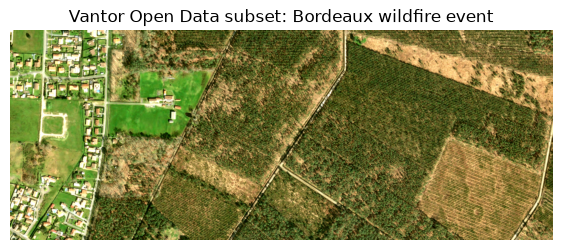

In [16]:
vantor_subset = save_single_asset_subset(
    item=vantor_item,
    asset_key=vantor_asset_key,
    bbox_wgs84=vantor_bbox,
    output_path="data/raw/vantor/vantor_bordeaux_event_rgb_subset.tif",
    band_indexes=(1, 2, 3),
)

plot_rgb(vantor_subset, "Vantor Open Data subset: Bordeaux wildfire event")

Project check: event-based imagery can be highly relevant for disaster mapping, but the coverage is limited to released events. Always check the event, date, licence and whether your intended use is allowed.

```{warning}
Vantor Open Data licensing and event availability should be checked directly in the collection metadata before using images in a public repository or report.
```

---

### SWISSIMAGE data: UZH Campus Irchel

For projects in Switzerland, SWISSIMAGE can be useful because it provides very high-resolution aerial imagery. At 10 cm resolution, even a small area can become a large raster.

The key classroom pattern is:

```text
Search bbox: WGS84 coordinates
Loaded data: often Swiss projected CRS, such as EPSG:2056
```

The notebook code below uses the swisstopo STAC search endpoint, groups tiles by year, and mosaics the same Campus Irchel extent across available years. This keeps the example focused on a small area while avoiding visible tile boundaries.

In [17]:
import requests
from collections import defaultdict

# WGS84 bounding box around UZH Campus Irchel
irchel_bbox_wgs84 = [8.550, 47.3970, 8.5535, 47.3995]

# Swiss orthophotos are distributed in LV95 (EPSG:2056); transform the
# bbox once so rasterio.merge can mosaic tiles to this exact extent.
transformer = Transformer.from_crs("EPSG:4326", "EPSG:2056", always_xy=True)
minx, miny = transformer.transform(*irchel_bbox_wgs84[:2])
maxx, maxy = transformer.transform(*irchel_bbox_wgs84[2:])
irchel_bounds_lv95 = (minx, miny, maxx, maxy)

collection_id = "ch.swisstopo.swissimage-dop10"
search_url = "https://data.geo.admin.ch/api/stac/v0.9/search"

response = requests.post(
    search_url,
    json={"collections": [collection_id], "bbox": irchel_bbox_wgs84, "limit": 100},
)
response.raise_for_status()
swissimage_items = response.json().get("features", [])

# SWISSIMAGE tiles are flown in different years; group all tiles that
# intersect the bbox by year so each year can be mosaicked separately.
yearly_tiles = defaultdict(list)
for item in swissimage_items:
    year = item.get("properties", {}).get("datetime", "").split("-")[0] or "Unknown"
    for asset in item.get("assets", {}).values():
        if "image/tiff" in asset.get("type", ""):
            yearly_tiles[year].append(asset.get("href"))
            break

sorted_years = sorted(yearly_tiles)
print(f"Found imagery across {len(sorted_years)} years: {sorted_years}")
for year in sorted_years:
    print(f"  {year}: {len(yearly_tiles[year])} tile(s) to mosaic")

Found imagery across 3 years: ['2019', '2022', '2025']
  2019: 2 tile(s) to mosaic
  2022: 2 tile(s) to mosaic
  2025: 2 tile(s) to mosaic


Mosaic all tiles that intersect the bbox for each year, so tile boundaries do not show, and compare the exact same extent across years.

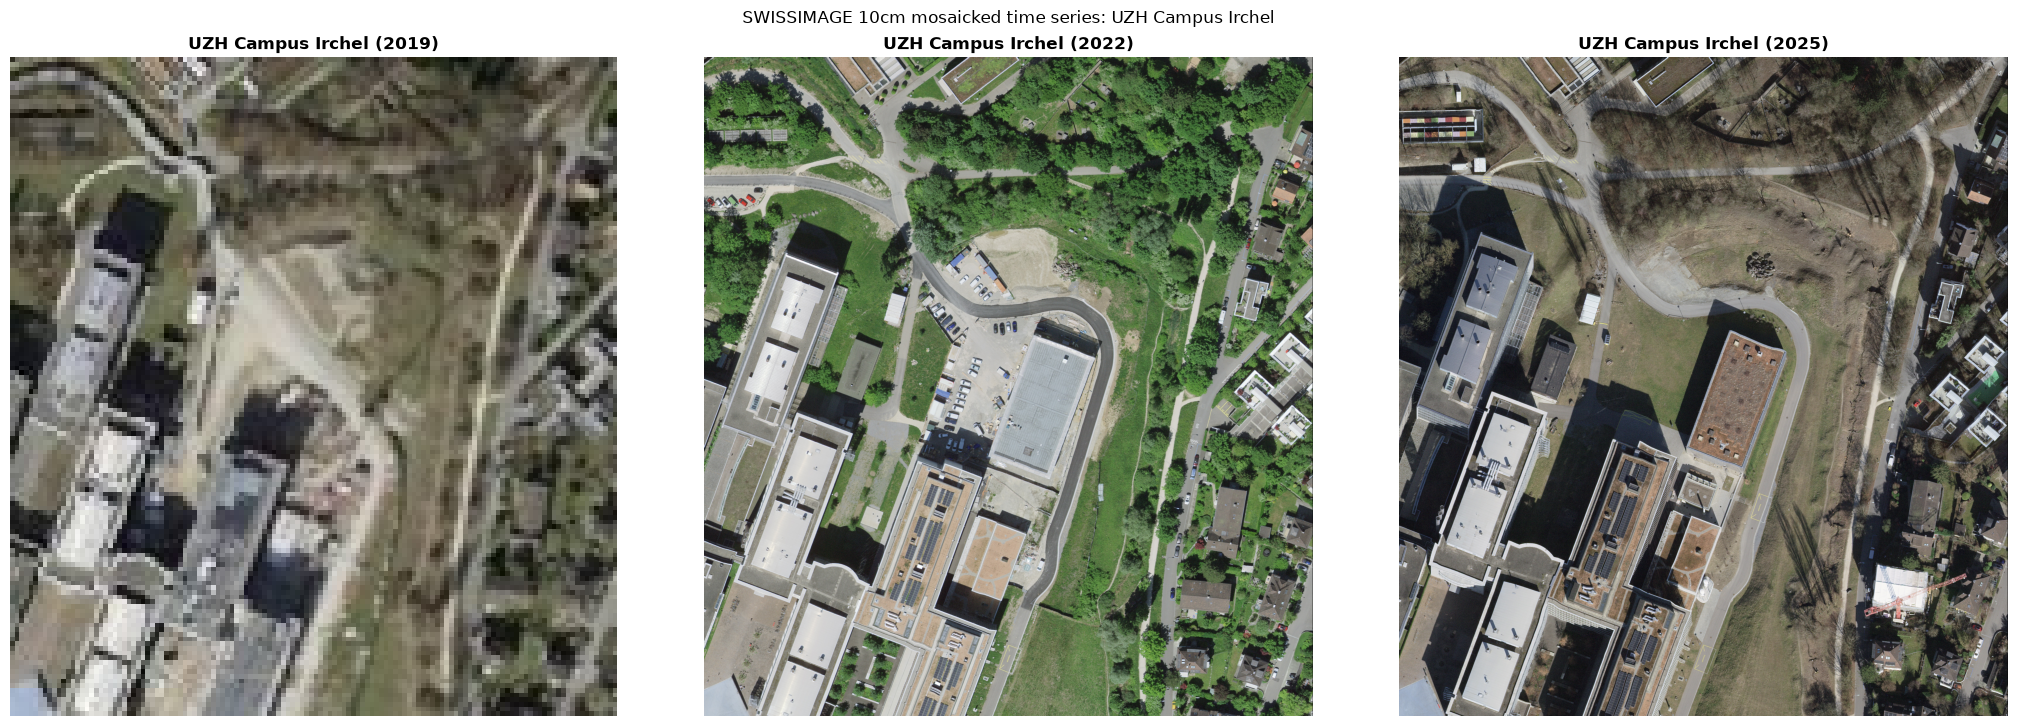

In [18]:
from rasterio.merge import merge

fig, axes = plt.subplots(1, len(sorted_years), figsize=(7 * len(sorted_years), 7))
if len(sorted_years) == 1:
    axes = [axes]

for ax, year in zip(axes, sorted_years):
    try:
        src_files = [rasterio.open(url) for url in yearly_tiles[year]]
        mosaic, _ = merge(src_files, bounds=irchel_bounds_lv95, indexes=[1, 2, 3])
        for src in src_files:
            src.close()

        rgb = np.clip(np.transpose(mosaic, (1, 2, 0)).astype(float) / 255.0, 0, 1)
        ax.imshow(rgb)
        ax.set_title(f"UZH Campus Irchel ({year})", fontweight="bold")
    except Exception as e:
        ax.text(
            0.5,
            0.5,
            f"Error: {e}",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="red",
        )
    ax.axis("off")

plt.tight_layout()
plt.suptitle("SWISSIMAGE 10cm mosaicked time series: UZH Campus Irchel", y=1.03)
plt.show()

Mosaicking to an exact extent like this keeps you in control of the area and years you need, without downloading full scenes or letting tile seams show. Without subsetting, large raster files can become impractical for quick inspection.

Project check: SWISSIMAGE is excellent for detailed visual inspection in Switzerland, but its resolution can quickly create large arrays. Keep test areas small and document the CRS transformation clearly.

<!-- TODO: add an optional export cell for the SWISSIMAGE mosaic if students need a local GeoTIFF for later preprocessing. -->

---

## Inspect your subset before using it

After creating a subset, inspect the saved file. This is the quality gate between data acquisition and preprocessing.

In [19]:
def inspect_raster(path):
    with rasterio.open(path) as src:
        print("Path:", path)
        print("Width x height:", src.width, "x", src.height)
        print("Bands:", src.count)
        print("CRS:", src.crs)
        print("Resolution:", src.res)
        print("Bounds:", src.bounds)
        print("Data type:", src.dtypes[0])
        print("File size:", f"{Path(path).stat().st_size / 1_000_000:.2f} MB")

In [20]:
inspect_raster(s2_subset)

Path: data/raw/sentinel2/s2_rome_rgb_subset.tif
Width x height: 816 x 367
Bands: 3
CRS: EPSG:32632
Resolution: (10.0, 10.0)
Bounds: BoundingBox(left=783786.3687304799, bottom=4642108.004359249, right=791946.3687304799, top=4645778.004359249)
Data type: uint16
File size: 1.39 MB


Run the same check for the other subsets you create.

Use the output to decide whether the subset is ready for the next step.

| Check | Why it matters |
|---|---|
| Width and height | Shows whether the subset is small enough to handle and large enough to inspect. |
| Bands | Confirms whether you downloaded the expected band combination. |
| CRS | Helps avoid spatial misalignment later. |
| Resolution | Shows whether the data can capture your target feature. |
| Bounds | Confirms that the subset covers the intended area. |
| File size | Helps keep project storage and repository decisions realistic. |

---

## Python reactivation

Remote sensing search and download workflows often use familiar Python building blocks:

| Python idea | Where it appears |
|---|---|
| {term}`List` | Bounding boxes and lists of bands. |
| {term}`Dictionary` | Query filters such as cloud-cover thresholds. |
| {term}`Loop` | Inspecting collections, items and assets. |
| {term}`Function` | Reusing subset and plotting code. |
| {term}`Pathlib` | Creating output folders and file paths. |

Example:

In [21]:
query_filter = {"eo:cloud_cover": {"lt": 20}}
bands = ["B04", "B03", "B02"]

for band in bands:
    print("Requested band:", band)

Requested band: B04
Requested band: B03
Requested band: B02


Keep project parameters visible near the top of your notebook:

In [22]:
project_area = "rome"
bbox_wgs84 = [12.43, 41.88, 12.49, 41.91]
date_range = "2025-06-01/2025-08-31"
max_cloud_cover = 20

This makes your workflow easier to adapt and document.

---

## Flags & checks

Use this table when your imagery workflow becomes confusing, fails unexpectedly or produces data that are too large.

| Red flag | First check |
|---|---|
| Search returns no items | Check bbox order, date range, collection ID and whether the collection covers the area. |
| Too many items are returned | Narrow the bbox, date range or quality filter. |
| The saved subset is too large | Reduce the bbox, number of bands or number of years. |
| The subset looks blurry or blocky | Check source resolution and whether the target feature is visible at that resolution. |
| The subset looks too dark or washed out | Apply or adjust the percentile stretch for display. |
| The image appears in the wrong place | Check search CRS, output CRS and bbox coordinates. |
| Bands appear in strange colours | Check band order before plotting an {term}`RGB Composite`. |
| Cloud cover is low but the image looks cloudy | Inspect the actual image and quality layers, not only metadata. |
| Asset names differ from the example | Print `item.assets.keys()` and choose assets manually. |
| The workflow only works for one location | Move bbox, date range, collection ID and output paths into project parameters. |

---

## Mini task: create one spatial subset for your project

Create a subset of imagery for your own project area. Choose the source, bounding box and bands based on what makes sense for your project question.

Try to keep the subset manageable. For a first test, aim for a file below about 100 MB. If the file is larger, shrink the bounding box before continuing.

Document:

```text
Data source:
Catalog:
Collection:
Bounding box:
Date range:
Selected item:
Selected assets:
Output file:
File size:
What the subset shows:
Main limitation:
Next project decision:
```

:::{note} Sample solution
:class: dropdown

```text
Data source: Sentinel-2 Level-2A
Catalog: Microsoft Planetary Computer STAC API
Collection: sentinel-2-l2a
Bounding box: WGS84 coordinates of the project area
Date range: summer 2025
Selected item: least-cloudy item returned by the search
Selected assets: B04, B03, B02
Output file: data/raw/sentinel2/s2_project_area_rgb_subset.tif
File size: checked with inspect_raster()
What the subset shows: land-cover patterns, vegetation and urban structure
Main limitation: 10 m resolution is not suitable for detecting very small objects
Next project decision: decide whether Sentinel-2 is detailed enough or whether higher-resolution imagery is needed
```

:::

---

## Key takeaways

- Search metadata before downloading imagery.
- The Planetary Computer catalogue helps you discover available datasets and collection IDs.
- STAC separates catalogs, collections, items and assets.
- Small spatial subsets are safer than full-scene downloads during project exploration.
- Always inspect CRS, resolution, bands, bounds, file size and visual plausibility.
- A subset is useful for project decisions, but final analysis may need native-resolution data and clearer preprocessing.